Hierarchical clustering completed and plots generated!


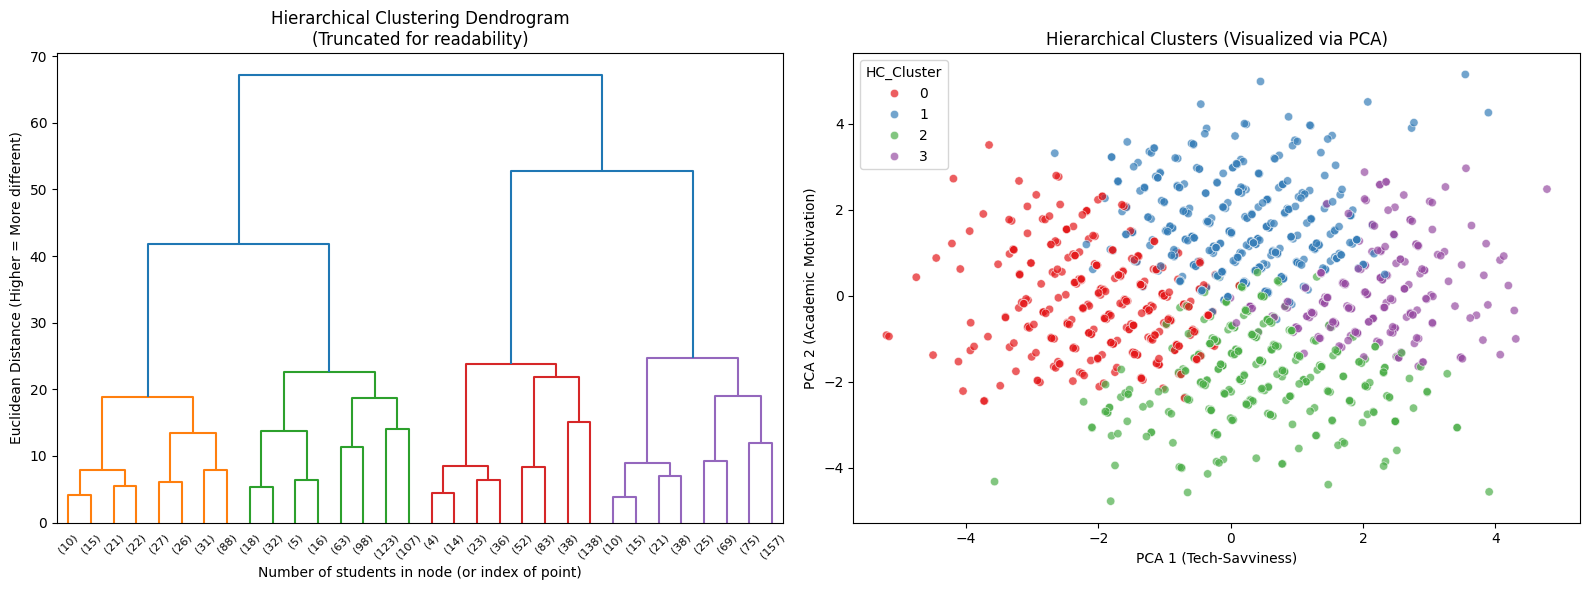

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import AgglomerativeClustering
import scipy.cluster.hierarchy as sch

# 1. Load the survey dataset
df_survey = pd.read_csv('student_survey_fa.csv')

# Make sure we only grab the 6 survey columns (in case K-Means added extra columns to the dataframe in memory, though we read from CSV)
survey_cols = ['Q1_Coding_Skill', 'Q2_Software_Adaptability', 'Q3_Troubleshooting', 'Q4_Study_Hours', 'Q5_Assignment_Punctuality', 'Q6_Class_Attendance']
X = df_survey[survey_cols]

# 2. Standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. Plotting Setup
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot A: The Dendrogram
axes[0].set_title('Hierarchical Clustering Dendrogram\n(Truncated for readability)')
# We truncate the tree because plotting 1500 individual branches is visually impossible!
dendrogram = sch.dendrogram(
    sch.linkage(X_scaled, method='ward'), 
    ax=axes[0], 
    truncate_mode='level', 
    p=4, # Only show the top 4 levels of the tree
    color_threshold=35 # Color the main 4 branches
)
axes[0].set_xlabel('Number of students in node (or index of point)')
axes[0].set_ylabel('Euclidean Distance (Higher = More different)')

# 4. Fit the Hierarchical Model (Agglomerative)
# We tell it to cut the tree where there are 4 clusters
hc = AgglomerativeClustering(n_clusters=4, metric='euclidean', linkage='ward')
clusters = hc.fit_predict(X_scaled)

# Add cluster labels back
df_survey['HC_Cluster'] = clusters

# 5. Visualizing the Clusters (Using PCA again to get 2D)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
df_survey['PCA1'] = X_pca[:, 0]
df_survey['PCA2'] = X_pca[:, 1]

# Plot B: The Scatter Plot
sns.scatterplot(x='PCA1', y='PCA2', hue='HC_Cluster', palette='Set1', data=df_survey, alpha=0.7, ax=axes[1])
axes[1].set_title('Hierarchical Clusters (Visualized via PCA)')
axes[1].set_xlabel('PCA 1 (Tech-Savviness)')
axes[1].set_ylabel('PCA 2 (Academic Motivation)')

plt.tight_layout()
plt.savefig('hierarchical_clusters.png')
print("Hierarchical clustering completed and plots generated!")